# Feature Analysis and Model Training

In this notebook I explore the relationship between my economic features and the median house price. This is in order to build my final model based on the most relevant features. Through analysing the correlation between my features and target I was able to identify and remove features that are likely to add noise and contribute little to forecasting median house prices.

Following feature selection, I compare the performance of two models, XGBoost and Lasso regression to access their predictive ability on a larger feature set.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd
from sqlalchemy import create_engine



## Loading and Preparing Data

Based on the feature importance plot created from my initial XGBoost model, both *month* and *quarter* features held virtually no importance in the models performance and thus I have excluded them from the final model dataset.

In [2]:
#Loading in dataset and setting index
model_data = pd.read_csv('processed/model_data.csv', index_col=0, parse_dates=True)

#Converting index to a datetime object
model_data.index = pd.to_datetime(model_data.index) 

model_data

,region,regionCode,LAcode,LA,median,average,hpi,change,base,5year,...,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,quarter,month,year
Date,,,,,,,,,,,,,,,,,,,,,
1995-12-01,East Midlands,12000004,4,ALL,48882.446000,43957.0,18.7,1.5,6.63,8.14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,12,1995
1996-01-01,East Midlands,12000004,4,ALL,48915.630857,42965.0,18.3,-2.3,6.38,8.13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1996
1996-02-01,East Midlands,12000004,4,ALL,48948.815714,42856.0,18.2,-0.3,6.13,7.87,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1996
1996-03-01,East Midlands,12000004,4,ALL,48982.000571,43515.0,18.5,1.5,6.13,7.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1996
1996-04-01,East Midlands,12000004,4,ALL,49046.851143,44010.0,18.7,1.1,5.94,7.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,4,1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-01,Yorkshire and The Humber,12000003,6000014,York,315085.760000,194000.0,101.2,-0.7,5.25,5.02,...,310768.91,310493.43,310217.96,309263.02,308308.07,307353.13,305956.00,4,11,2023
2023-12-01,Yorkshire and The Humber,12000003,6000014,York,316014.580000,193000.0,100.5,-0.7,5.25,4.89,...,311044.38,310768.91,310493.43,310217.96,309263.02,308308.07,307353.13,4,12,2023
2024-01-01,Yorkshire and The Humber,12000003,6000014,York,317287.120000,192000.0,100.0,-0.5,5.25,4.68,...,311772.30,311044.38,310768.91,310493.43,310217.96,309263.02,308308.07,1,1,2024


## Correlation Analysis

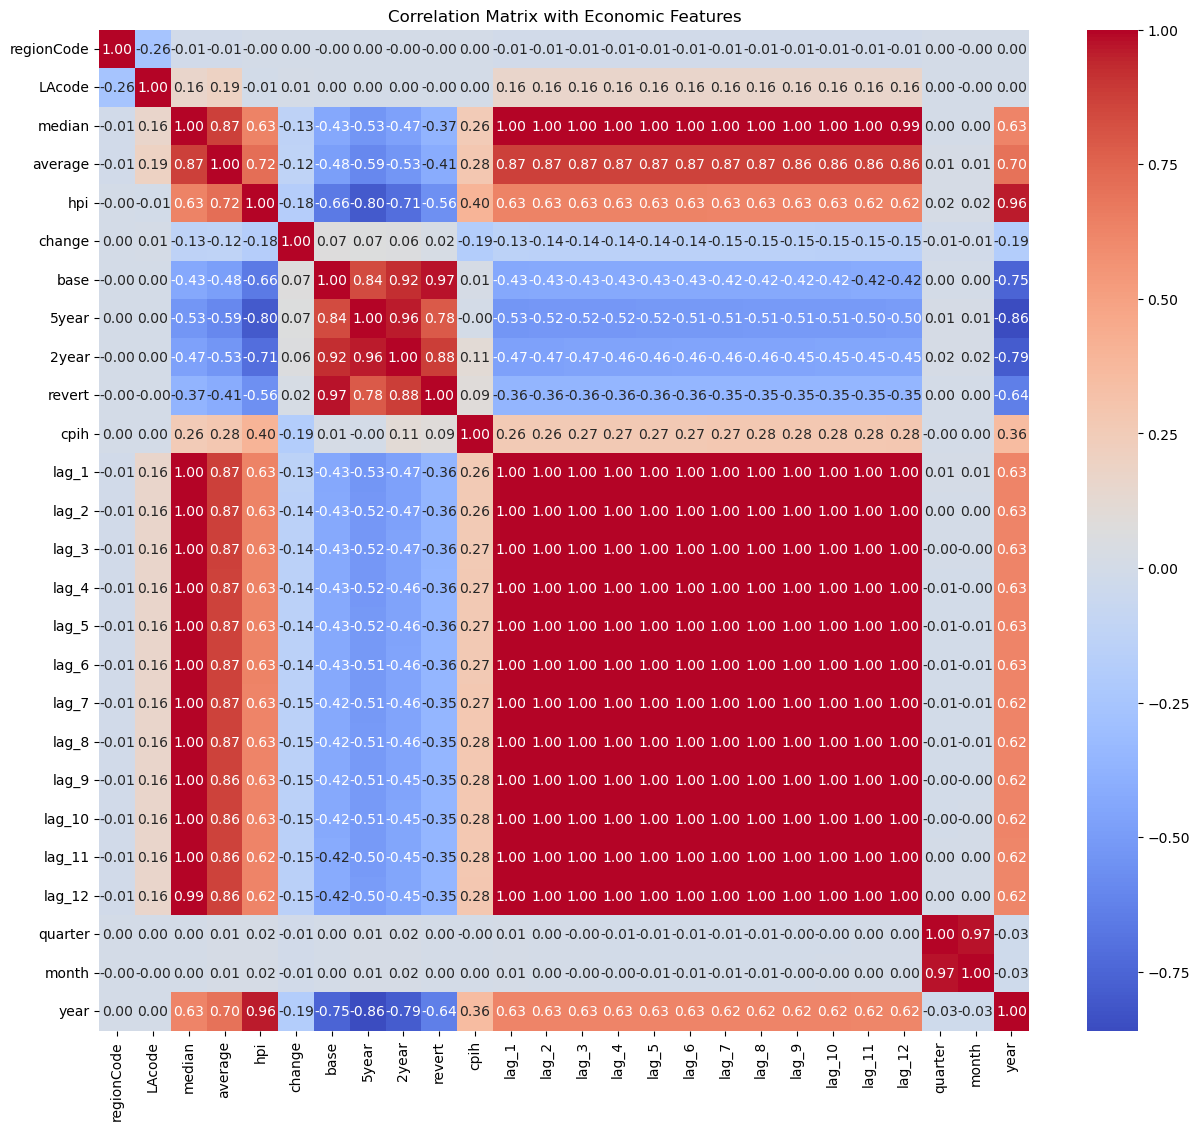

In [3]:
#Selecting only numerical data
numeric_data = model_data.select_dtypes(include=['number'])

#Buliding correlation matrix
correlations = numeric_data.corr()

plt.figure(figsize=(15, 13))
sns.heatmap(correlations, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix with Economic Features")
plt.show()


## Visual Exploration
Here I am exploring the relationship between the different mortgage rates and median house prices. This is in order to determine whether they will be informative in predicting house prices.

In [4]:
#Filtering for England data
england_data = model_data[model_data['region'] == 'England'].copy()

In [5]:
england_data

,region,regionCode,LAcode,LA,median,average,hpi,change,base,5year,...,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,quarter,month,year
Date,,,,,,,,,,,,,,,,,,,,,
1995-12-01,England,92000001,10,England,55000.00,49965.0,17.5,0.3,6.63,8.14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,12,1995
1996-01-01,England,92000001,10,England,55000.00,49410.0,17.3,-1.1,6.38,8.13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1996
1996-02-01,England,92000001,10,England,55000.00,49601.0,17.4,0.4,6.13,7.87,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1996
1996-03-01,England,92000001,10,England,55000.00,49739.0,17.4,0.3,6.13,7.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1996
1996-04-01,England,92000001,10,England,55166.67,50352.0,17.6,1.2,5.94,7.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,4,1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-01,England,92000001,10,England,291666.67,281000.0,98.3,-0.7,5.25,5.02,...,299298.33,298646.67,297995.00,296996.67,295998.33,295000.00,291666.67,4,11,2023
2023-12-01,England,92000001,10,England,290000.00,279000.0,97.5,-0.8,5.25,4.89,...,299950.00,299298.33,298646.67,297995.00,296996.67,295998.33,295000.00,4,12,2023
2024-01-01,England,92000001,10,England,289166.67,278000.0,97.3,-0.2,5.25,4.68,...,298300.00,299950.00,299298.33,298646.67,297995.00,296996.67,295998.33,1,1,2024


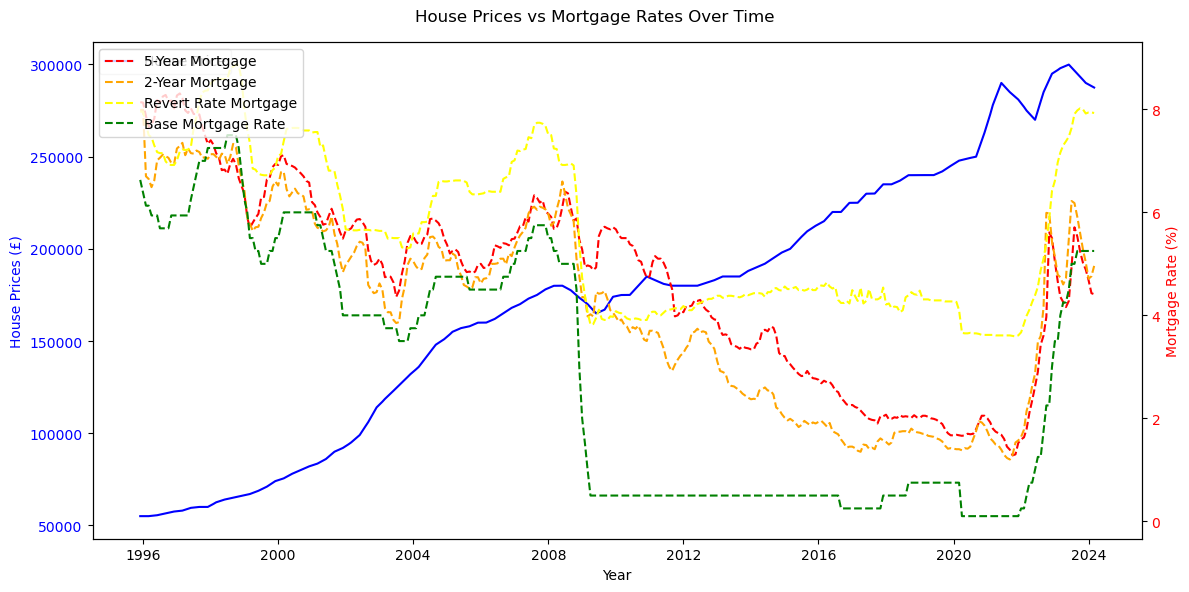

In [6]:
fig, ax1 = plt.subplots(figsize=(12,6))

#Plotting median house prices on primary y-axis
ax1.set_xlabel("Year")
ax1.set_ylabel("House Prices (£)", color="blue")
ax1.plot(england_data.index, england_data["median"], label="House Price", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

#Creating secondary y-axis for mortgage rates
ax2 = ax1.twinx()
ax2.set_ylabel("Mortgage Rate (%)", color="red")
ax2.plot(england_data.index, england_data["5year"], label="5-Year Mortgage", color="red", linestyle="dashed")
ax2.plot(england_data.index, england_data["2year"], label="2-Year Mortgage", color="orange", linestyle="dashed")
ax2.plot(england_data.index, england_data["revert"], label="Revert Rate Mortgage", color="yellow", linestyle="dashed")
ax2.plot(england_data.index, england_data["base"], label="Base Mortgage Rate", color="green", linestyle="dashed")
ax2.tick_params(axis="y", labelcolor="red")

ax1.legend(loc="upper left")
ax2.legend(loc="upper left")

# Title and layout
fig.suptitle("House Prices vs Mortgage Rates Over Time")
fig.tight_layout()
plt.show()


Here I can see an inverse relationship between house prices and both the 5 year mortgage rates and 2 year mortgage rate. Where as the base bank rate seems redundant to include as it falls flat between the year of 2009 to 2022. Along with this the revert rate seems to have a weak influence on house price trends making them both weak predictors. For these reasons I have dropped both the revert rate and base bank rate as features for the final model.

Features I have dropped and why:
- **Lag Features (2,3,4,9,11 and 12)**
    - These have been removed as they have been identified in the previous notebook as having little to no importance based on the baseline model's feature importance scores.
- CPIH
    - Weak correlation with the median house price

In [7]:
numeric_data = model_data.select_dtypes(include=['number'])
numeric_data = numeric_data.dropna()

In [8]:
# Train-test split for both models
train = numeric_data.loc[numeric_data.index < '2022-01-01'] 
test = numeric_data.loc[numeric_data.index >= '2022-01-01']

## Training XGBoost Model using full features

In [9]:
# Step 5: Define features
TARGET = 'median'
FEATURES = ['lag_1','lag_2','lag_4','lag_3','lag_5','lag_9','lag_12','LAcode','hpi']

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [10]:
xgboost1 = XGBRegressor(base_score=0.5, booster='gbtree',    
                       n_estimators=1000,
                       objective='reg:squarederror',
                       max_depth=3,
                       learning_rate=0.01)
xgboost1.fit(X_train, y_train,
        eval_set=[(X_train, y_train)],
        verbose=100)

[0]	validation_0-rmse:222573.62376
[100]	validation_0-rmse:83004.09378
[200]	validation_0-rmse:32084.92033
[300]	validation_0-rmse:14331.76191
[400]	validation_0-rmse:8791.38814
[500]	validation_0-rmse:7356.34046
[600]	validation_0-rmse:6403.27038
[700]	validation_0-rmse:5541.58308
[800]	validation_0-rmse:4988.35566
[900]	validation_0-rmse:4665.31705
[999]	validation_0-rmse:4481.20757


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [11]:
y_test_pred = xgboost1.predict(X_test)

#Prediction measures
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
r2 = r2_score(y_test, y_test_pred)


print(f'XGBoost RMSE: £{rmse:,.2f}')
print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost MAPE: {mape:.2f}%")
print(f"XGBoost r2: {r2:.2f}")

XGBoost RMSE: £22,690.40
XGBoost MAE: 5426.78
XGBoost MAPE: 1.04%
XGBoost r2: 0.98


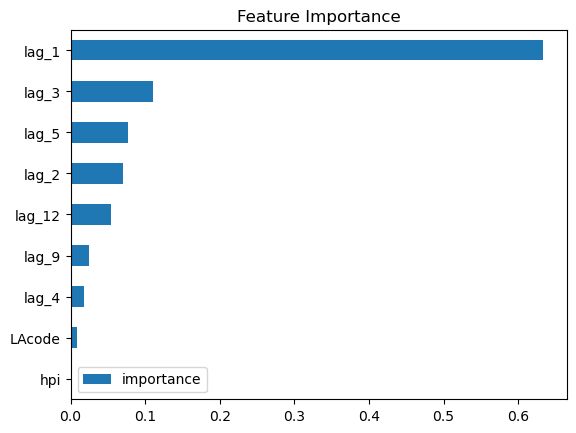

In [12]:
#Visualising feature importance
fi = pd.DataFrame(data=xgboost1.feature_importances_,
             index=xgboost1.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

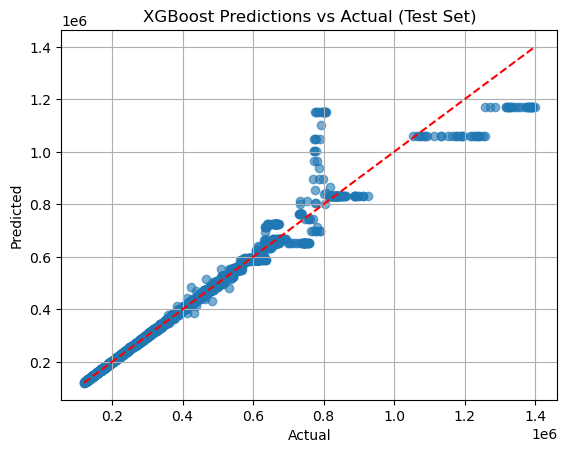

In [13]:
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost Predictions vs Actual (Test Set)")
plt.grid(True)
plt.show()


# Training XGBoost using full features 

In [14]:
#Preparing data set for third iteration XGBoost model
xgb_data = model_data.copy()
xgb_data = xgb_data.select_dtypes(include=['number'])
xgb_data = xgb_data.sort_index()

Here I am applying a 3 month rolling mean to features that had been identified in the feature importance plot. This is to smooth noise and improve model stability.

In [15]:

window = 3

#Smoothing economic indicators
xgb_data['average_roll3'] = xgb_data['average'].rolling(window).mean().shift(1)
xgb_data['cpih_roll3'] = xgb_data['cpih'].rolling(window).mean().shift(1)
xgb_data['hpi_roll3'] = xgb_data['hpi'].rolling(window).mean().shift(1)
xgb_data['5year_roll3'] = xgb_data['5year'].rolling(window).mean().shift(1)
xgb_data['2year_roll3'] = xgb_data['2year'].rolling(window).mean().shift(1)

#Smooth lag features
xgb_data['lag_1_roll3'] = xgb_data['lag_1'].rolling(window).mean().shift(1)
xgb_data['lag_2_roll3'] = xgb_data['lag_2'].rolling(window).mean().shift(1) 

#Dropping NaNs
xgb_data.dropna(inplace=True)

#Selecting only numerical features
numeric_data = xgb_data.select_dtypes(include=['number'])


# Train/Test Split

In [16]:
# Define target and features
TARGET = 'median'
FEATURES = [col for col in numeric_data.columns if col != TARGET]

# Train-test split
train = numeric_data.loc[numeric_data.index < '2022-01-01']
test  = numeric_data.loc[numeric_data.index >= '2022-01-01']

X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

# XGBoost 

In [17]:
# Train model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# Fit with early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train)],
    verbose=100
)

[0]	validation_0-rmse:114864.08501
[100]	validation_0-rmse:3540.03245
[200]	validation_0-rmse:2465.62865
[300]	validation_0-rmse:2063.40876
[400]	validation_0-rmse:1819.98329
[499]	validation_0-rmse:1664.07245


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [18]:
# Predict and inverse transform if needed
y_test_pred = xgb_model.predict(X_test)


# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
r2 = r2_score(y_test, y_test_pred)


print(f"XGBoost RMSE: £{rmse:,.2f}")
print(f"XGBoost MAE: £{mae:,.2f}")
print(f"XGBoost MAPE: {mape:.2f}%")
print(f"XGBoost r2: {r2:.2f}")

XGBoost RMSE: £21,477.48
XGBoost MAE: £6,033.21
XGBoost MAPE: 1.21%
XGBoost r2: 0.98


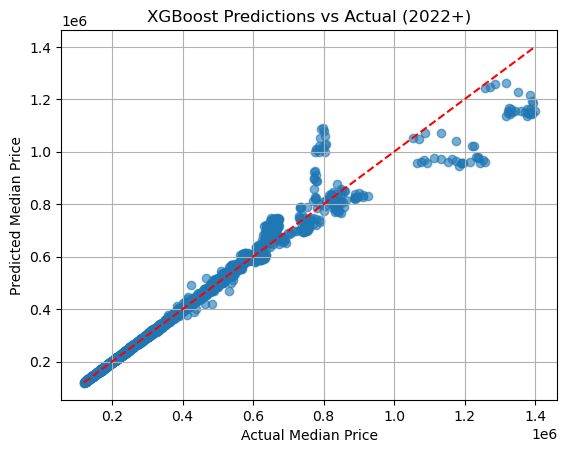

In [19]:
# Plot predicted vs actual
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Median Price")
plt.ylabel("Predicted Median Price")
plt.title("XGBoost Predictions vs Actual (2022+)")
plt.grid(True)
plt.show()

In [20]:
def plot_predictions_by_lacode(lacode, y_pred, target='median'):
    # Filter train and test
    train_la = train[train['LAcode'] == lacode].copy()
    test_la = test[test['LAcode'] == lacode].copy()

    # Create Series for y_pred with same index as test
    y_pred_series = pd.Series(y_pred, index=test.index)

    # Assign predictions directly using .index.values to avoid reindex errors
    test_la['y_pred'] = y_pred_series.loc[test_la.index.values].values

    # Combine and plot
    full_la = pd.concat([train_la, test_la])

    plt.figure(figsize=(15, 5))
    plt.plot(full_la.index, full_la[target], label='Truth Data', color='steelblue')
    plt.plot(test_la.index, test_la['y_pred'], label='Prediction', color='orange')
    plt.axvline(pd.to_datetime('2022-01-01'), color='black', linestyle='--', label='Train/Test Split')

    plt.title(f'LAcode {lacode}: XGBoost Predictions vs Actual')
    plt.xlabel('Date')
    plt.ylabel('Median Price (£)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



# LASSO Model

In [21]:
# Initialize the scaler
scaler = StandardScaler()

# Fit only on training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# training LASSO model
lasso_model = LassoCV(random_state=42, cv=5, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

y_test_pred_lasso = lasso_model.predict(X_test_scaled)

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_test_pred_lasso)
lasso_mape = mean_absolute_percentage_error(y_test, y_test_pred_lasso) * 100
lasso_r2 = r2_score(y_test, y_test_pred_lasso)

print(f"Lasso RMSE (Test): £{lasso_rmse:,.2f}")
print(f"XGBoost MAE: £{lasso_mae:,.2f}")
print(f"Lasso MAPE (Test): {lasso_mape:.2f}%")
print(f"Lasso r2 (Test): {lasso_r2:.2f}")

Lasso RMSE (Test): £3,734.33
XGBoost MAE: £2,554.90
Lasso MAPE (Test): 0.81%
Lasso r2 (Test): 1.00


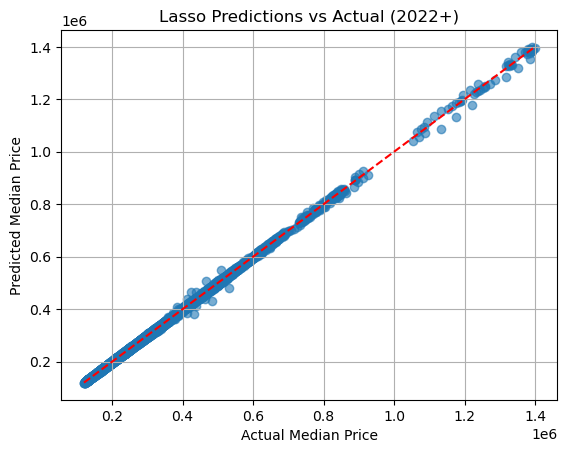

In [22]:
# Plot predicted vs actual
plt.scatter(y_test, y_test_pred_lasso, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Median Price")
plt.ylabel("Predicted Median Price")
plt.title("Lasso Predictions vs Actual (2022+)")
plt.grid(True)
plt.show()

In [23]:
test_with_preds_lasso = test.copy()
test_with_preds_lasso['y_pred'] = y_test_pred_lasso


In [24]:
def plot_predictions_by_lacode(lacode, test_with_preds, target='median'):
    train_la = train[train['LAcode'] == lacode].copy()
    test_la = test_with_preds[test_with_preds['LAcode'] == lacode].copy()

    # Combine and plot
    full_la = pd.concat([train_la, test_la])

    plt.figure(figsize=(15, 5))
    plt.plot(full_la.index, full_la[target], label='Truth Data', color='steelblue')
    plt.plot(test_la.index, test_la['y_pred'], label='Prediction', color='orange')
    plt.axvline(pd.to_datetime('2022-01-01'), color='black', linestyle='--', label='Train/Test Split')

    plt.title(f'LAcode {lacode}: XGBoost Predictions vs Actual')
    plt.xlabel('Date')
    plt.ylabel('Median Price (£)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


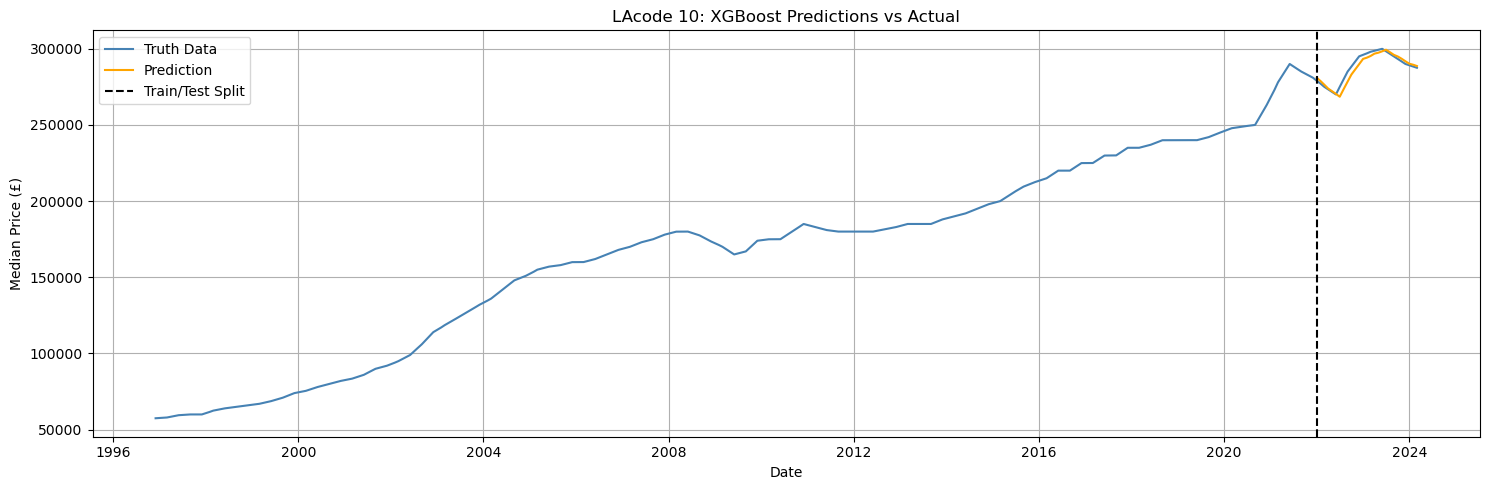

In [25]:
plot_predictions_by_lacode(10, test_with_preds_lasso)



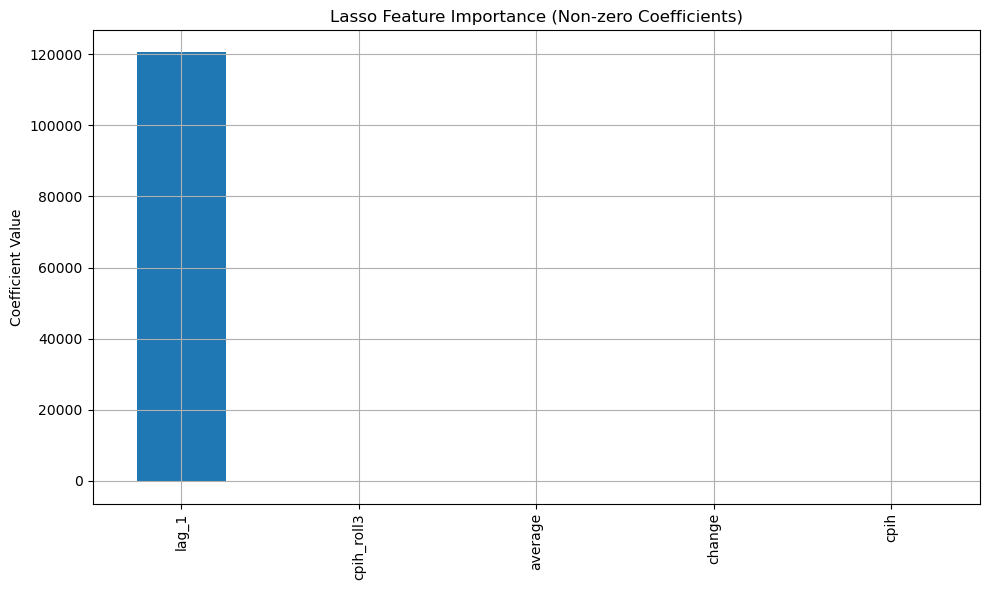

In [26]:
# Get feature names and coefficients
lasso_coef = pd.Series(lasso_model.coef_, index=X_train.columns)

# Filter out zero coefficients (optional)
non_zero_coef = lasso_coef[lasso_coef != 0]

# Sort by absolute value
non_zero_coef = non_zero_coef.reindex(non_zero_coef.abs().sort_values(ascending=False).index)

# Plot
plt.figure(figsize=(10, 6))
non_zero_coef.plot(kind='bar')
plt.title('Lasso Feature Importance (Non-zero Coefficients)')
plt.ylabel('Coefficient Value')
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
selected_features = ['median', 'lag_1', 'cpih_roll3', 'average', 'change','cpih','LAcode']
lasso_data = xgb_data[selected_features].copy()
lasso_data

,median,lag_1,cpih_roll3,average,change,cpih,LAcode
Date,,,,,,,
1996-12-01,39937.92,39903.95,3.1,40338.0,-0.4,2.8,6000047
1996-12-01,82225.00,81852.99,3.0,58337.0,0.9,2.8,7000096
1996-12-01,64912.95,64479.43,2.9,58337.0,0.9,2.8,7000070
1996-12-01,45736.11,45589.46,2.8,45876.0,0.7,2.8,7000137
1996-12-01,50468.06,50252.04,2.8,69290.0,1.2,2.8,6000046
...,...,...,...,...,...,...,...
2024-03-01,501569.44,500745.37,3.8,368000.0,-0.4,3.8,7000211
2024-03-01,380000.00,380674.24,3.8,368000.0,-0.4,3.8,7000064
2024-03-01,490450.00,490756.67,3.8,368000.0,-0.4,3.8,7000212


In [28]:
# Define target and features
TARGET = 'median'
FEATURES = [col for col in lasso_data.columns if col != TARGET]

# Train-test split
train = lasso_data.loc[lasso_data.index < '2022-01-01']
test  = lasso_data.loc[lasso_data.index >= '2022-01-01']

X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

In [29]:
# Initialize the scaler
scaler = StandardScaler()

# Fit only on training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# training LASSO model
lasso_model = LassoCV(random_state=42, cv=5, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

y_test_pred_lasso = lasso_model.predict(X_test_scaled)

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_test_pred_lasso)
lasso_mape = mean_absolute_percentage_error(y_test, y_test_pred_lasso) * 100
lasso_r2 = r2_score(y_test, y_test_pred_lasso)

print(f"Lasso RMSE (Final): £{lasso_rmse:,.2f}")
print(f"Lasso MAE (Final): £{lasso_mae:,.2f}")
print(f"Lasso MAPE (Final): {lasso_mape:.2f}%")
print(f"Lasso r2 (Final): {lasso_r2:.2f}")

Lasso RMSE (Final): £3,739.70
Lasso MAE (Final): £2,561.70
Lasso MAPE (Final): 0.81%
Lasso r2 (Final): 1.00


## Creating a hybrid model

In [30]:
y_pred_hybrid = 0.7 * y_test_pred_lasso + 0.3 * y_test_pred

rmse = np.sqrt(mean_squared_error(y_test, y_pred_hybrid))
mae = mean_absolute_error(y_test, y_pred_hybrid)
mape = mean_absolute_percentage_error(y_test, y_pred_hybrid) * 100
r2 = r2_score(y_test, y_pred_hybrid)

print(f"✅ Hybrid RMSE: £{rmse:,.2f}")
print(f"✅ Hybrid MAE: £{mae:,.2f}")
print(f"✅ Hybrid MAPE: {mape:.2f}%")
print(f"✅ Hybrid R²: {r2:.4f}")

✅ Hybrid RMSE: £7,263.09
✅ Hybrid MAE: £3,321.72
✅ Hybrid MAPE: 0.88%
✅ Hybrid R²: 0.9979


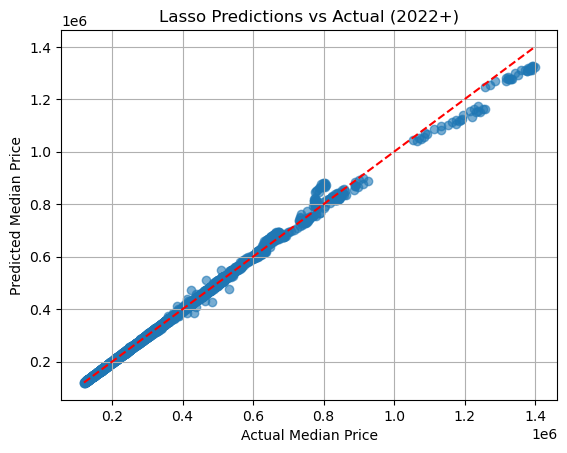

In [31]:
# Plot predicted vs actual
plt.scatter(y_test, y_pred_hybrid, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Median Price")
plt.ylabel("Predicted Median Price")
plt.title("Lasso Predictions vs Actual (2022+)")
plt.grid(True)
plt.show()

## Saving Trained Models

In [32]:
model_path = "models/lasso_final_model.pkl"
joblib.dump(lasso_model, model_path)

['models/lasso_final_model.pkl']

In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

n_months = 4
forecast_list = []

# Get latest month from dataset
full_data = xgb_data.sort_index()
latest_month = full_data.index.max()

# Loop through each unique LAcode
for la_code in full_data['LAcode'].dropna().unique():

    la_data = full_data[full_data['LAcode'] == la_code].copy()
    la_data = la_data.sort_index()

    # Skip if not enough history
    if la_data.shape[0] < 12:
        continue

    latest_inputs = la_data.iloc[-1].copy()

    for i in range(1, n_months + 1):
        future_date = latest_month + pd.DateOffset(months=i)

        # Shift lag features
        for lag in range(12, 1, -1):
            latest_inputs[f'lag_{lag}'] = latest_inputs.get(f'lag_{lag - 1}', np.nan)
        latest_inputs['lag_1'] = latest_inputs['median']

        # Update date-related features
        latest_inputs['month'] = future_date.month
        latest_inputs['quarter'] = ((future_date.month - 1) // 3) + 1
        latest_inputs['year'] = future_date.year

        # Drop target and format
        input_row = latest_inputs.drop('median')
        X_future = pd.DataFrame([input_row])[X_train.columns]
        X_future_scaled = scaler.transform(X_future)

        # Predict
        pred = lasso_model.predict(X_future_scaled)[0]

        # Store prediction
        forecast_list.append({
            'LAcode': la_code,
            'Date': future_date,
            'predicted_median': pred
        })

        # Update latest_inputs for next step
        latest_inputs['median'] = pred

# Combine results
forecast_df = pd.DataFrame(forecast_list)
forecast_df = forecast_df.set_index('Date').sort_index()

# ✅ Now `forecast_df` has 4 rows per LAcode, one per future month
print(forecast_df[forecast_df['LAcode'] == 10
      ])


            LAcode  predicted_median
Date                                
2024-04-01      10     287803.015945
2024-05-01      10     288106.502851
2024-06-01      10     288410.461449
2024-07-01      10     288714.892473


In [34]:
forecast_df

,LAcode,predicted_median
Date,,
2024-04-01,6000047,130639.136933
2024-04-01,7000234,342610.084691
2024-04-01,7000134,271806.080603
2024-04-01,6000058,358791.909283
2024-04-01,7000112,314243.700477
...,...,...
2024-07-01,6000033,354395.364469
2024-07-01,8000013,175329.631290
2024-07-01,7000136,202517.915503


In [35]:
# Step 1: Reset index and rename
forecast_df = forecast_df.reset_index()
lasso_data = lasso_data.reset_index()

forecast_df = forecast_df.rename(columns={'predicted_median': 'median'})

# Step 2: Add missing columns with NaNs
for col in lasso_data.columns:
    if col not in forecast_df.columns:
        forecast_df[col] = np.nan

# Step 3: Match column order
forecast_df = forecast_df[lasso_data.columns]

# Step 4: Append to xgb_data
lasso_data_with_forecast = pd.concat([lasso_data, forecast_df], ignore_index=True).sort_values('Date')

# Step 5: Optional – set index back to datetime
lasso_data_with_forecast.set_index('Date', inplace=True)


In [37]:
lasso_data_with_forecast

,median,lag_1,cpih_roll3,average,change,cpih,LAcode
Date,,,,,,,
1996-12-01,39937.920000,39903.95,3.1,40338.0,-0.4,2.8,6000047
1996-12-01,72233.780000,71915.30,2.8,87161.0,1.5,2.8,9000008
1996-12-01,63436.400000,63393.63,2.8,87161.0,1.5,2.8,9000012
1996-12-01,42641.130000,42439.43,2.8,41542.0,0.4,2.8,8000010
1996-12-01,44966.630000,44630.44,2.8,45876.0,0.7,2.8,6000061
...,...,...,...,...,...,...,...
2024-07-01,415793.954417,NaN,NaN,NaN,NaN,NaN,6000022
2024-07-01,499493.605190,NaN,NaN,NaN,NaN,NaN,7000217
2024-07-01,569852.791654,NaN,NaN,NaN,NaN,NaN,9000009


## Saving Final Dataset

In [38]:
lasso_data_with_forecast.to_csv('processed/final_data.csv', index=True)